In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# (i)  LOAD DATASET
df = pd.read_csv('smart_city_monitor.csv')

print(" Dataset Loaded")
print(f"  Shape   : {df.shape}  → {df.shape[0]} samples, {df.shape[1]} features")
print(f"\n  Features ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"    {i:>2}. {col}")

#print("\n  First 5 rows:")
#print(df.head().to_string(index=False))
print("\n  Statistical Summary:\n")
print(df.describe().round(2))

 Dataset Loaded
  Shape   : (100, 20)  → 100 samples, 20 features

  Features (20):
     1. traffic_density
     2. vehicle_count
     3. avg_speed_kmph
     4. road_occupancy
     5. signal_wait_time
     6. air_quality_index
     7. co2_level
     8. pm25_level
     9. noise_level_db
    10. humidity_pct
    11. power_consumption_kw
    12. solar_output_kw
    13. water_usage_liters
    14. waste_generated_kg
    15. smart_meter_reading
    16. temperature_c
    17. rainfall_mm
    18. crowd_density
    19. wifi_usage_gb
    20. cctv_alerts

  Statistical Summary:

       traffic_density  vehicle_count  avg_speed_kmph  road_occupancy  \
count           100.00         100.00          100.00          100.00   
mean            197.42         494.25           60.69           68.54   
std              26.85          45.20            9.89           14.43   
min             132.17         385.46           36.49           25.07   
25%             181.26         465.62           54.38        

In [6]:
# (ii)  STANDARDIZE the dataset

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print(" After Standardization (mean=0, std=1)")

print(f"  Mean (all features should be ~0):")
print(f"  {X_scaled.mean().round(6).values}")
print(f"\n  Std  (all features should be ~1):")
print(f"  {X_scaled.std().round(6).values}")

 After Standardization (mean=0, std=1)
  Mean (all features should be ~0):
  [ 0. -0.  0. -0. -0. -0. -0.  0. -0.  0.  0.  0. -0. -0.  0. -0. -0.  0.
  0. -0.]

  Std  (all features should be ~1):
  [1.005038 1.005038 1.005038 1.005038 1.005038 1.005038 1.005038 1.005038
 1.005038 1.005038 1.005038 1.005038 1.005038 1.005038 1.005038 1.005038
 1.005038 1.005038 1.005038 1.005038]


In [7]:
# (iii)  APPLY PCA 

pca_full = PCA(n_components=20, random_state=42)
pca_full.fit(X_scaled)

explained_var      = pca_full.explained_variance_ratio_
cumulative_var     = np.cumsum(explained_var)

print(" PCA — Explained Variance per Component")

print(f"\n  {'PC':<6} {'Variance Explained':>20} {'Cumulative Variance':>22}")
print("  " + "-" * 52)
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    bar = '' * int(ev * 100)
    print(f"  PC{i:<4} {ev*100:>15.2f}%      {cv*100:>15.2f}%   {bar}")

 PCA — Explained Variance per Component

  PC       Variance Explained    Cumulative Variance
  ----------------------------------------------------
  PC1              29.22%                29.22%   
  PC2              23.24%                52.46%   
  PC3              19.67%                72.13%   
  PC4               6.24%                78.37%   
  PC5               5.24%                83.62%   
  PC6               4.88%                88.50%   
  PC7               4.17%                92.68%   
  PC8               3.62%                96.30%   
  PC9               0.76%                97.06%   
  PC10              0.46%                97.52%   
  PC11              0.40%                97.92%   
  PC12              0.38%                98.29%   
  PC13              0.34%                98.63%   
  PC14              0.26%                98.89%   
  PC15              0.25%                99.14%   
  PC16              0.22%                99.37%   
  PC17              0.20%          

In [8]:
# (iv)  NUMBER OF COMPONENTS to retain 95% variance

n_95  = np.argmax(cumulative_var >= 0.95) + 1
n_90  = np.argmax(cumulative_var >= 0.90) + 1
n_85  = np.argmax(cumulative_var >= 0.85) + 1

print(" Components Required to Retain Variance")

print(f"  To retain 85% variance → {n_85}  principal components")
print(f"  To retain 90% variance → {n_90}  principal components")
print(f"  To retain 95% variance → {n_95}  principal components")
print(f"\n   Chosen: {n_95} components  (retains 95% of information)")
print(f"     Reduced from 20 features → {n_95} components")
print(f"     Dimensionality reduced by {((20 - n_95)/20)*100:.1f}%")

 Components Required to Retain Variance
  To retain 85% variance → 6  principal components
  To retain 90% variance → 7  principal components
  To retain 95% variance → 8  principal components

   Chosen: 8 components  (retains 95% of information)
     Reduced from 20 features → 8 components
     Dimensionality reduced by 60.0%


In [9]:
# (v)  TRANSFORM dataset into reduced feature space
pca_reduced        = PCA(n_components=n_95, random_state=42)
X_reduced          = pca_reduced.fit_transform(X_scaled)

pc_cols            = [f'PC{i}' for i in range(1, n_95 + 1)]
df_reduced         = pd.DataFrame(X_reduced, columns=pc_cols)


print(f"   Transformed Dataset  ({df.shape[0]} samples × {n_95} components)")
print(df_reduced.round(4).head(10).to_string(index=False))
print(f"\n  Original shape : {df.shape}")
print(f"  Reduced shape  : {df_reduced.shape}")

   Transformed Dataset  (100 samples × 8 components)
    PC1     PC2     PC3     PC4     PC5     PC6     PC7     PC8
 2.0879 -1.7834 -0.6109 -0.5835  0.6445  1.8413 -0.8247 -1.2081
 0.8898 -0.5725 -1.8953 -0.7301 -0.8063 -0.0291 -0.8696  0.0468
 2.8860  0.4587  0.2022 -0.6749  0.3713 -1.4063  0.4270  0.0350
 4.5082 -0.8650  0.6978  0.3756 -2.6783 -0.0122  0.7604 -0.3889
-2.0457 -1.9484  1.0608 -2.0750 -1.1119 -1.5022  0.9697 -0.0931
-1.6538 -0.9926  1.6060  1.1060 -1.8030  0.2477  1.3069  0.1746
 1.7866  3.6232  4.0136  0.1003  0.9006 -1.3882 -0.4424 -0.0813
 2.4737  0.8136  1.0893 -0.2543  1.4233  0.4262  0.9312  0.1608
-0.5302  0.7886 -1.1079  0.8025  0.4510 -1.5430  0.8925  1.5433
 6.0363  4.2888 -2.3562  0.1759 -0.2380  1.2960 -0.3765  1.6454

  Original shape : (100, 20)
  Reduced shape  : (100, 8)


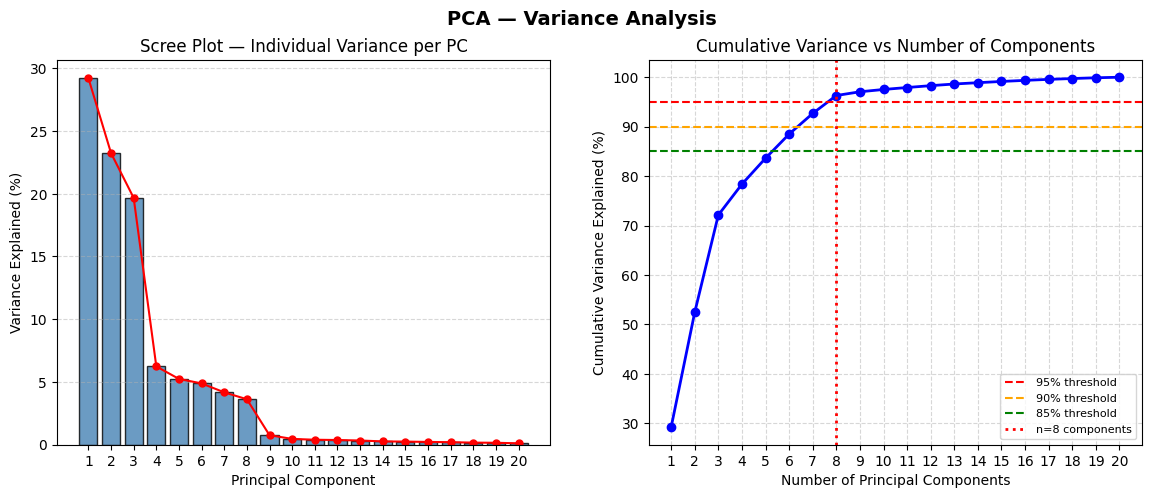

In [10]:
# (vi)  VISUALIZATIONS

# PLOT 1 : Scree Plot + Cumulative Variance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA — Variance Analysis', fontsize=14, fontweight='bold')

x_pc = range(1, 21)

# Scree plot (individual variance)

axes[0].bar(x_pc, explained_var * 100, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].plot(x_pc, explained_var * 100, 'ro-', markersize=5)
axes[0].set_title('Scree Plot — Individual Variance per PC')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_xticks(x_pc)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Cumulative variance

axes[1].plot(x_pc, cumulative_var * 100, 'bo-', linewidth=2, markersize=6)
axes[1].axhline(95, color='red',    linestyle='--', label='95% threshold')
axes[1].axhline(90, color='orange', linestyle='--', label='90% threshold')
axes[1].axhline(85, color='green',  linestyle='--', label='85% threshold')
axes[1].axvline(n_95, color='red', linestyle=':', linewidth=2, label=f'n={n_95} components')
axes[1].set_title('Cumulative Variance vs Number of Components')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_xticks(x_pc)
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.show()

Text(0.5, 1.0, 'Before PCA — Feature Correlation Matrix\n(shows why PCA is useful: many correlated features)')

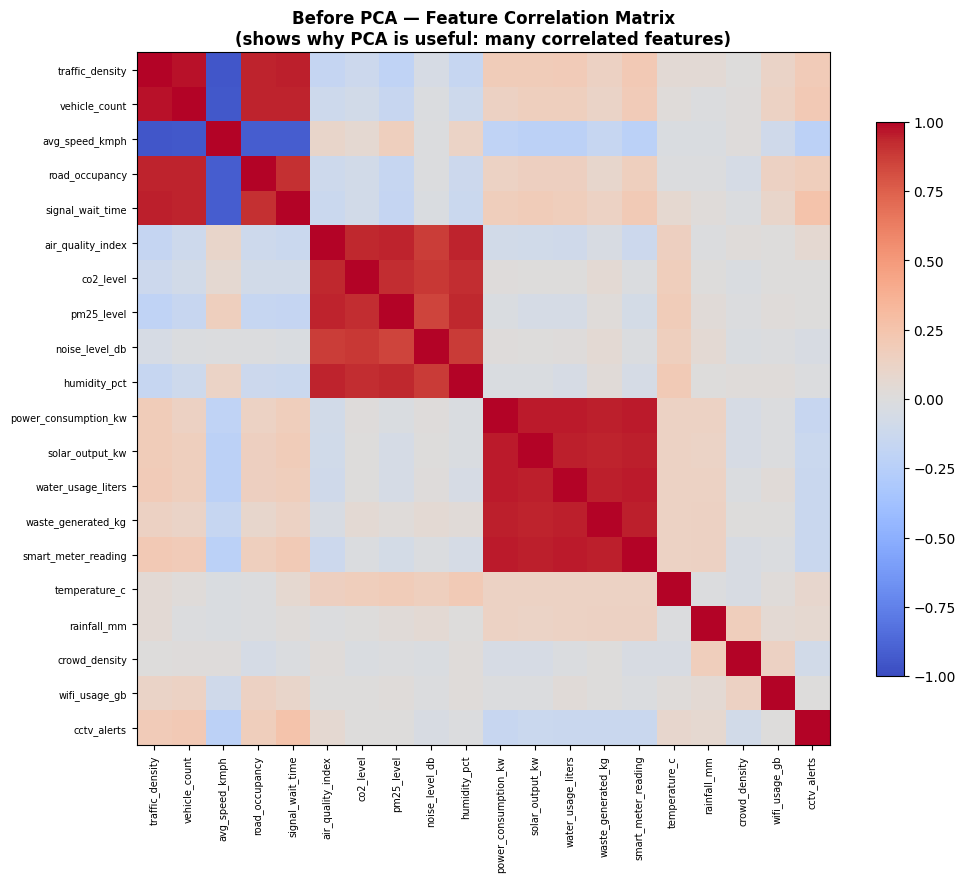

In [11]:
# PLOT 2 : Before PCA — Heatmap of feature correlation

corr = df.corr().round(2)

plt.figure(figsize=(12, 9))
im = plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, shrink=0.8)
plt.xticks(range(20), df.columns, rotation=90, fontsize=7)
plt.yticks(range(20), df.columns, fontsize=7)
plt.title('Before PCA — Feature Correlation Matrix\n(shows why PCA is useful: many correlated features)',fontsize=12, fontweight='bold')

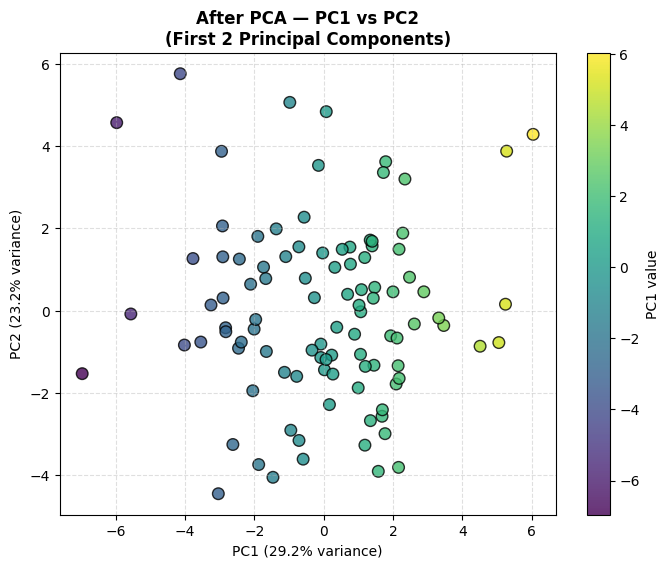

In [12]:
# PLOT 3 : After PCA — Scatter plot of PC1 vs PC2

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_reduced['PC1'], df_reduced['PC2'],
                      c=df_reduced['PC1'], cmap='viridis',
                      edgecolors='black', s=70, alpha=0.8)
plt.colorbar(scatter, label='PC1 value')
plt.title('After PCA — PC1 vs PC2\n(First 2 Principal Components)',
          fontsize=12, fontweight='bold')
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
plt.grid(True, linestyle='--', alpha=0.4)

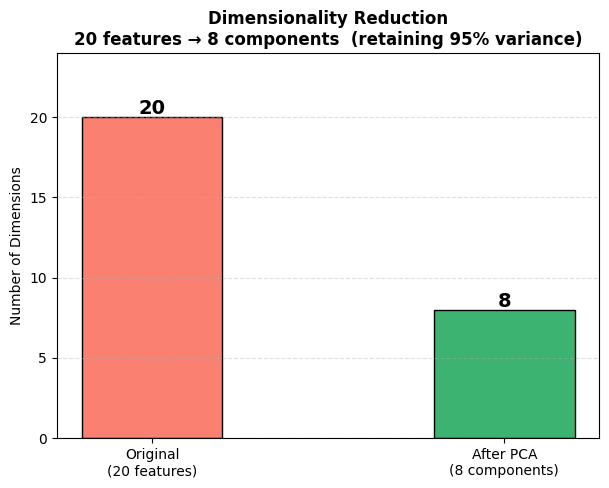

In [13]:
# PLOT 4 : Before vs After — shape comparison bar chart

fig, ax = plt.subplots(figsize=(7, 5))

categories = ['Original\n(20 features)', f'After PCA\n({n_95} components)']
values     = [20, n_95]
colors     = ['salmon', 'mediumseagreen']

bars = ax.bar(categories, values, color=colors, edgecolor='black',
              width=0.4)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
            str(v), ha='center', fontsize=14, fontweight='bold')

ax.set_title(f'Dimensionality Reduction\n20 features → {n_95} components  '
             f'(retaining 95% variance)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Dimensions')
ax.set_ylim(0, 24)
ax.grid(axis='y', linestyle='--', alpha=0.4)

In [14]:
#  FINAL SUMMARY

print("  SUMMARY")
print(f"  Original dimensions        : 20 features")
print(f"  After PCA (95% variance)   : {n_95} components")
print(f"  Dimensionality reduced by  : {((20-n_95)/20)*100:.1f}%")
print(f"  Variance retained          : {cumulative_var[n_95-1]*100:.2f}%")
print(f"  Information lost           : {(1-cumulative_var[n_95-1])*100:.2f}%")
print(f"\n   Key Observations:")
print(f"  1. PCA compressed 20 features into {n_95} components with minimal loss.")
print(f"  2. First 2 PCs explain {(explained_var[0]+explained_var[1])*100:.1f}% of variance alone.")
print(f"  3. Correlated features (traffic, pollution, energy groups)")
print(f"     were captured efficiently by fewer components.")
print(f"  4. Reduced data can speed up ML model training significantly.")

  SUMMARY
  Original dimensions        : 20 features
  After PCA (95% variance)   : 8 components
  Dimensionality reduced by  : 60.0%
  Variance retained          : 96.30%
  Information lost           : 3.70%

   Key Observations:
  1. PCA compressed 20 features into 8 components with minimal loss.
  2. First 2 PCs explain 52.5% of variance alone.
  3. Correlated features (traffic, pollution, energy groups)
     were captured efficiently by fewer components.
  4. Reduced data can speed up ML model training significantly.
